# Edge Node Local Model Training

## Overview

In an edge computing architecture, raw sensor data is processed locally on distributed nodes.
Each simulated **edge node** will independently train an anomaly-detection model using its own subset of SWaT sensor measurements.
This workflow mirrors a realistic industrial monitoring setup where multiple sites or stages operate autonomously and only share model parameters during federated learning.

### Goals:
- Load previously created edge node datasets
- Train a separate **Random Forest** classifier per node to identify attack instances
- Evaluate each model and record performance metrics
- Persist models to disk for later aggregation
- Visualize and compare results across nodes

The trained edge models will be combined in subsequent notebooks to explore federated learning strategies.

## Import Required Libraries

In [7]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import joblib
import warnings
warnings.filterwarnings('ignore')

# Visualization defaults
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## Define Edge Nodes

In [8]:
edge_nodes = [
    "Edge_Node_1",
    "Edge_Node_2",
    "Edge_Node_3",
    "Edge_Node_4",
    "Edge_Node_5",
    "Edge_Node_6"
]

print(f"✓ Defined {len(edge_nodes)} edge nodes")

✓ Defined 6 edge nodes


## Initialize Results Storage

In [9]:
edge_results = []  # will hold dicts of performance metrics

# ensure directories exist
Path('models').mkdir(parents=True, exist_ok=True)
Path('results/statistics').mkdir(parents=True, exist_ok=True)
Path('results/figures').mkdir(parents=True, exist_ok=True)

print("✓ Result storage and directories initialized")

✓ Result storage and directories initialized


## Loop Through Edge Nodes

In [10]:
for node in edge_nodes:
    print(f"\n--- Processing {node} ---")

    normal_path = f'data/processed/edge_nodes/{node}_normal.csv'
    attack_path = f'data/processed/edge_nodes/{node}_attack.csv'

    df_normal = pd.read_csv(normal_path)
    df_attack = pd.read_csv(attack_path)

    df = pd.concat([df_normal, df_attack], ignore_index=True)
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)

    print(f"    combined shape: {df.shape}")

    globals()[f'{node}_df'] = df

print("\n✓ All edge node datasets loaded and shuffled")


--- Processing Edge_Node_1 ---
    combined shape: (1441719, 6)

--- Processing Edge_Node_2 ---
    combined shape: (1441719, 8)

--- Processing Edge_Node_3 ---
    combined shape: (1441719, 9)

--- Processing Edge_Node_4 ---
    combined shape: (1441719, 10)

--- Processing Edge_Node_5 ---
    combined shape: (1441719, 11)

--- Processing Edge_Node_6 ---
    combined shape: (1441719, 8)

✓ All edge node datasets loaded and shuffled


## Train/Test Split

In [11]:
RANDOM_STATE = 42

for node in edge_nodes:
    df = globals()[f'{node}_df']
    X = df.drop('Attack', axis=1)
    y = df['Attack']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )

    globals()[f'{node}_X_train'] = X_train
    globals()[f'{node}_X_test'] = X_test
    globals()[f'{node}_y_train'] = y_train
    globals()[f'{node}_y_test'] = y_test

    print(f"{node}: train {X_train.shape}, test {X_test.shape}")

print("\n✓ Train/test split completed for all nodes")

Edge_Node_1: train (1153375, 5), test (288344, 5)
Edge_Node_2: train (1153375, 7), test (288344, 7)
Edge_Node_3: train (1153375, 8), test (288344, 8)
Edge_Node_4: train (1153375, 9), test (288344, 9)
Edge_Node_5: train (1153375, 10), test (288344, 10)
Edge_Node_6: train (1153375, 7), test (288344, 7)

✓ Train/test split completed for all nodes


## Train Random Forest Model

In [12]:
for node in edge_nodes:
    print(f"\nTraining model for {node}...")

    X_train = globals()[f'{node}_X_train']
    y_train = globals()[f'{node}_y_train']

    clf = RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )
    clf.fit(X_train, y_train)

    globals()[f'{node}_model'] = clf

    print(f"  ✓ Model trained ({len(X_train)} samples)")

print("\n✓ All node models trained")


Training model for Edge_Node_1...
  ✓ Model trained (1153375 samples)

Training model for Edge_Node_2...
  ✓ Model trained (1153375 samples)

Training model for Edge_Node_3...
  ✓ Model trained (1153375 samples)

Training model for Edge_Node_4...
  ✓ Model trained (1153375 samples)

Training model for Edge_Node_5...
  ✓ Model trained (1153375 samples)

Training model for Edge_Node_6...
  ✓ Model trained (1153375 samples)

✓ All node models trained


## Model Evaluation

In [14]:
for node in edge_nodes:
    print(f"\nEvaluating {node}...")

    clf = globals()[f'{node}_model']
    X_test = globals()[f'{node}_X_test']
    y_test = globals()[f'{node}_y_test']

    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    print(f"  Accuracy: {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall: {rec:.4f}")
    print(f"  F1-score: {f1:.4f}")
    print(f"  Confusion Matrix:{cm}")
    print(f"  Classification Report:{classification_report(y_test, y_pred)}")

    edge_results.append({
        'Edge_Node': node,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1
    })

print("\n✓ Evaluation complete and metrics recorded for all nodes")


Evaluating Edge_Node_1...


  Accuracy: 0.9778
  Precision: 0.7230
  Recall: 0.6693
  F1-score: 0.6951
  Confusion Matrix:[[274619   2801]
 [  3613   7311]]
  Classification Report:              precision    recall  f1-score   support

           0       0.99      0.99      0.99    277420
           1       0.72      0.67      0.70     10924

    accuracy                           0.98    288344
   macro avg       0.86      0.83      0.84    288344
weighted avg       0.98      0.98      0.98    288344


Evaluating Edge_Node_2...
  Accuracy: 0.9997
  Precision: 0.9972
  Recall: 0.9957
  F1-score: 0.9964
  Confusion Matrix:[[277389     31]
 [    47  10877]]
  Classification Report:              precision    recall  f1-score   support

           0       1.00      1.00      1.00    277420
           1       1.00      1.00      1.00     10924

    accuracy                           1.00    288344
   macro avg       1.00      1.00      1.00    288344
weighted avg       1.00      1.00      1.00    288344


Evaluating E

## Save Models

In [15]:
for node in edge_nodes:
    clf = globals()[f'{node}_model']
    model_path = f'models/{node}_model.pkl'
    joblib.dump(clf, model_path)
    print(f"✓ Saved {node} model to {model_path}")

print("\nAll models saved successfully")

✓ Saved Edge_Node_1 model to models/Edge_Node_1_model.pkl
✓ Saved Edge_Node_2 model to models/Edge_Node_2_model.pkl
✓ Saved Edge_Node_3 model to models/Edge_Node_3_model.pkl
✓ Saved Edge_Node_4 model to models/Edge_Node_4_model.pkl
✓ Saved Edge_Node_5 model to models/Edge_Node_5_model.pkl
✓ Saved Edge_Node_6 model to models/Edge_Node_6_model.pkl

All models saved successfully


## Create Results DataFrame

In [16]:
results_df = pd.DataFrame(edge_results)
results_path = 'results/statistics/edge_node_model_performance.csv'
results_df.to_csv(results_path, index=False)
print(f"✓ Performance results saved to {results_path}")
print(results_df)

✓ Performance results saved to results/statistics/edge_node_model_performance.csv
     Edge_Node  Accuracy  Precision    Recall        F1
0  Edge_Node_1  0.977756   0.723002  0.669260  0.695094
1  Edge_Node_2  0.999729   0.997158  0.995698  0.996427
2  Edge_Node_3  0.988202   0.896312  0.778653  0.833350
3  Edge_Node_4  0.998814   0.990089  0.978488  0.984254
4  Edge_Node_5  0.999764   0.997799  0.995972  0.996885
5  Edge_Node_6  0.993088   0.926545  0.887953  0.906839


## Visualize Performance

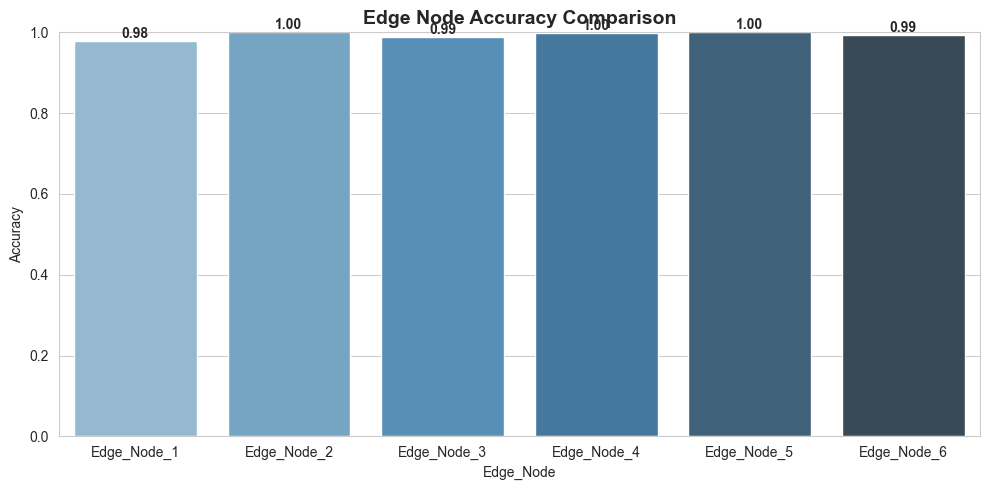

✓ Accuracy comparison chart saved: results/figures/edge_node_accuracy_comparison.png


In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x='Edge_Node', y='Accuracy', data=results_df, palette='Blues_d', ax=ax)
ax.set_title('Edge Node Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
fig.savefig('results/figures/edge_node_accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Accuracy comparison chart saved: results/figures/edge_node_accuracy_comparison.png")

## Feature Importance

In [18]:
for node in edge_nodes:
    clf = globals()[f'{node}_model']
    X_train = globals()[f'{node}_X_train']

    importances = clf.feature_importances_
    indices = np.argsort(importances)[::-1]
    features = X_train.columns

    top_n = min(10, len(features))
    top_features = features[indices][:top_n]
    top_importances = importances[indices][:top_n]

    fig, ax = plt.subplots(figsize=(8, 4))
    sns.barplot(x=top_importances, y=top_features, palette='viridis', ax=ax)
    ax.set_title(f'{node} Top Feature Importances', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    output_path = f'results/figures/{node}_feature_importance.png'
    fig.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f"✓ Saved feature importance for {node}: {output_path}")

print("\n✓ Feature importance plots generated for all nodes")

✓ Saved feature importance for Edge_Node_1: results/figures/Edge_Node_1_feature_importance.png
✓ Saved feature importance for Edge_Node_2: results/figures/Edge_Node_2_feature_importance.png
✓ Saved feature importance for Edge_Node_3: results/figures/Edge_Node_3_feature_importance.png
✓ Saved feature importance for Edge_Node_4: results/figures/Edge_Node_4_feature_importance.png
✓ Saved feature importance for Edge_Node_5: results/figures/Edge_Node_5_feature_importance.png
✓ Saved feature importance for Edge_Node_6: results/figures/Edge_Node_6_feature_importance.png

✓ Feature importance plots generated for all nodes


## Final Summary

In [19]:
print("="*80)
print("EDGE NODE LOCAL TRAINING SUMMARY")
print("="*80)

num_nodes = len(edge_nodes)
avg_acc = results_df['Accuracy'].mean()
best_node = results_df.loc[results_df['Accuracy'].idxmax(), 'Edge_Node']

print(f"\nNumber of edge nodes trained: {num_nodes}")
print(f"Average accuracy: {avg_acc:.4f}")
print(f"Best performing node: {best_node}")

print("\nThese local models are ready to be combined using federated learning in the next stage.")

EDGE NODE LOCAL TRAINING SUMMARY

Number of edge nodes trained: 6
Average accuracy: 0.9929
Best performing node: Edge_Node_5

These local models are ready to be combined using federated learning in the next stage.
